# EDA Dirigido — Fase 3: Gestión de Residuos Sólidos en Bogotá

Este notebook implementa el diseño de `Plan_EDA.md` (documento aprobado antes de escribir
código): un EDA organizado por las 6 categorías de variables del proyecto de grado, más una
sección dedicada a **interacciones entre actores** — porque la pregunta de investigación es
sobre eso, no sobre variables aisladas.

**Regla de alcance vigente:** las reglas de negocio del ABM se derivan *después* de este
EDA, a partir de su evidencia — no antes, y no de supuestos sin verificar.

**Fuentes que se cruzan aquí por primera vez** (todas ya descargadas y verificadas en
`Recoleccion_Datos_Fase2.md`): el RBL consolidado (2017-2026), el RURO oficial con datos de
formalización, los 4 snapshots de SIGAB, las macrorutas reales, y el microdato individual de la
Encuesta de Cultura Ambiental 2021.

Cada sección explica primero **qué técnica se usa y por qué** — este EDA es, a propósito, también
una guía de técnicas de visualización avanzada (mapas bivariados, pequeños múltiplos, gráficos de
pendiente, distribuciones comparadas), no solo un reporte de resultados.

In [1]:
import sys
from pathlib import Path

PROYECTO_DIR = Path.cwd()
if not (PROYECTO_DIR / "src").exists():
    PROYECTO_DIR = PROYECTO_DIR.parent
if str(PROYECTO_DIR) not in sys.path:
    sys.path.insert(0, str(PROYECTO_DIR))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from src import config, carga_datos, geoespacial, eda

eda.aplicar_estilo()
pd.set_option("display.width", 160)
print("Entorno configurado. PROYECTO_DIR:", PROYECTO_DIR)

Entorno configurado. PROYECTO_DIR: c:\Users\personal\Projects\Proyectos Manuel\EDA + ABM Residuos Bogota


## 0.1 Carga de todas las fuentes que usa este EDA

Nada se descarga aquí — todo viene de `data/processed/` (Fase 1) y `data/raw/externo_fase2/`
(Fase 2), ya verificado. Esta celda es intencionalmente la única "pesada" del notebook: el resto
son gráficos sobre estos DataFrames ya en memoria.

In [2]:
# --- Fase 1: el dataset ya construido y las tablas exportadas ---
df_modelo = pd.read_pickle(config.DATA_PROCESSED / "df_modelo.pkl")
anio_mas_reciente = df_modelo["AÑO"].max()
df_modelo_actual = df_modelo[df_modelo["AÑO"] == anio_mas_reciente].copy()
print(f"df_modelo: {df_modelo.shape}, año más reciente usado para mapas: {anio_mas_reciente}")

df_actores = pd.read_csv(config.DATA_PROCESSED / "05_actores.csv")
gdf_upz = carga_datos.cargar_upz_limites()

# --- Fase 2: recursos activados y recién conectados ---
df_rbl = pd.read_csv(config.DATA_PROCESSED / "15_rbl_consolidado.csv")

ruro_bloques = carga_datos.cargar_ruro_oficial_2012_2021()
df_ruro_2022 = carga_datos.cargar_ruro_2022_por_localidad()

sigab = {
    snap: carga_datos.cargar_sigab_snapshot(snap)
    for snap in ["sigab_2020", "sigab_2022_diciembre", "sigab_2024_diciembre", "sigab_2026_junio"]
}

gdf_macrorutas_recoleccion = carga_datos.cargar_macrorutas("recoleccion")
gdf_macrorutas_barrido = carga_datos.cargar_macrorutas("barrido")

df_eca = carga_datos.cargar_eca2021_microdatos()
diccionario_eca = carga_datos.cargar_diccionario_eca2021()

print("RBL:", df_rbl.shape, "| RURO 2022:", df_ruro_2022.shape, "| ECA microdato:", df_eca.shape)
print("Macrorutas recolección:", gdf_macrorutas_recoleccion.shape, "| barrido:", gdf_macrorutas_barrido.shape)

df_modelo: (784, 114), año más reciente usado para mapas: 2024


Advertencia: no se pudo leer sigab_contenedores.csv (Error tokenizing data. C error: Expected 13 fields in line 6876, saw 14
), se omite.


RBL: (2240, 7) | RURO 2022: (339, 17) | ECA microdato: (2282, 117)
Macrorutas recolección: (125, 10) | barrido: (179, 10)


In [3]:
def col_like(df: pd.DataFrame, *palabras_clave: str) -> str:
    """Devuelve el nombre real de la primera columna que contiene TODAS las palabras clave
    (insensible a mayúsculas/acentos). Los encabezados de la ECA 2021 son el texto literal de
    cada pregunta (largo, con tildes que a veces se leen distinto según el entorno) — buscar por
    palabra clave es más robusto que copiar el string exacto.
    """
    import unicodedata

    def normalizar(s):
        s = str(s).lower()
        return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")

    claves = [normalizar(p) for p in palabras_clave]
    for c in df.columns:
        c_norm = normalizar(c)
        if all(clave in c_norm for clave in claves):
            return c
    raise KeyError(f"No se encontró columna con las palabras clave {palabras_clave}")


# Geometría de UPZ + variables del año más reciente, para todos los mapas de este notebook.
# gdf_upz trae CODIGO_UPZ como texto (crudo del .gpkg); df_modelo lo tiene numérico — mismo
# patrón ya usado en abm/visualizacion_mapa.py para este mismo cruce.
gdf_upz["CODIGO_UPZ"] = pd.to_numeric(gdf_upz["CODIGO_UPZ"], errors="coerce")
gdf_upz_actual = gdf_upz.merge(
    df_modelo_actual, left_on="CODIGO_UPZ", right_on="CODIGO_UPZ", how="inner"
)
print("UPZ con geometría + variables:", gdf_upz_actual.shape)

UPZ con geometría + variables: (112, 127)


---
## 1. Separación en la fuente y calidad de la separación

**Técnica:** serie de tiempo simple para la tendencia agregada, mapa coroplético (color =
magnitud de una sola variable, la técnica correcta cuando la pregunta es "¿dónde es alto/bajo
esto?") para la variación espacial, y **por primera vez en este proyecto**, el microdato
individual de la ECA 2021 en vez del agregado por localidad — que permite ver razones y
dificultades reales declaradas por las personas, no solo un porcentaje.

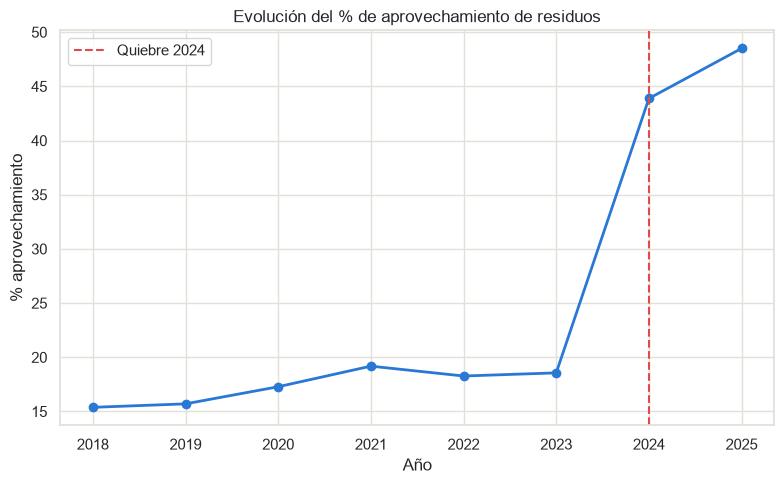

In [4]:
df_residuos_dj = carga_datos.cargar_disposicion_dj()
fig = eda.graficar_serie_tiempo_aprovechamiento(df_residuos_dj, "año", "Pct_Aprovechamiento")
plt.show()

**Lectura:** el quiebre 2023→2024 ya documentado en la Fase 1 sigue presente con los datos
consolidados. El mapa siguiente muestra si ese aprovechamiento se reparte parejo entre UPZ o si
hay concentración territorial — la pregunta central de la hipótesis original.

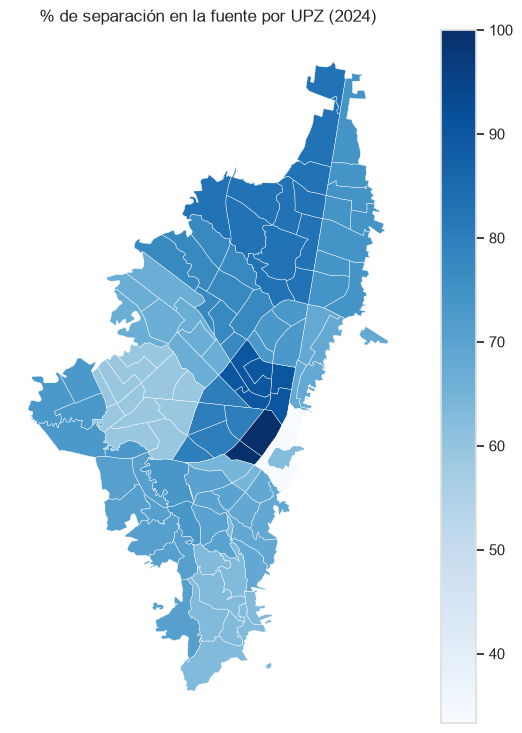

In [5]:
fig = eda.graficar_mapa_coropletico(
    gdf_upz_actual, "pct_separa_en_fuente",
    f"% de separación en la fuente por UPZ ({anio_mas_reciente})",
)
plt.show()

### Microdato ECA 2021: razones y dificultades reales (nunca antes explotado en este proyecto)

Hasta la Fase 2, este proyecto solo usaba el agregado de 20 filas por localidad. Aquí se usan las
~2,282 encuestas individuales para ver **por qué** la gente sí o no separa — información que
ningún agregado puede dar.

**Nota técnica importante (1):** las respuestas del microdato vienen como **códigos numéricos**
(1, 2, 99...), no como texto — por eso se cargó también `cargar_diccionario_eca2021()` (hoja
`DICCIONARIO` del archivo fuente), que traduce cada código a su etiqueta real. Graficar los
códigos sin traducir habría sido un error silencioso (barras con números en vez de razones).

**Nota técnica importante (2) — factor de expansión:** la ECA 2021 es una encuesta
**probabilística**, no un censo: cada persona encuestada representa a un número distinto de
personas reales de Bogotá (`PONDERADOR`, `FACTOR PERSONAS`, `FACTOR HOGARES` — verificado que
`PONDERADOR` normaliza a media 1 y suma exactamente 2,282, el tamaño de la muestra; `FACTOR
PERSONAS` suma ~6.08 millones, consistente con la población de 13+ años de Bogotá). **Contar
respuestas crudas (como se hizo en una primera versión de este notebook) subestima o sobreestima
sistemáticamente según qué estratos/localidades quedaron sobre- o sub-representados en la
muestra** — no es un detalle menor, es la diferencia entre describir la muestra y describir la
ciudad. De aquí en adelante se usa `PONDERADOR` en todos los conteos y pruebas de esta sección,
mostrando también la versión sin ponderar para que se vea cuánto cambia.

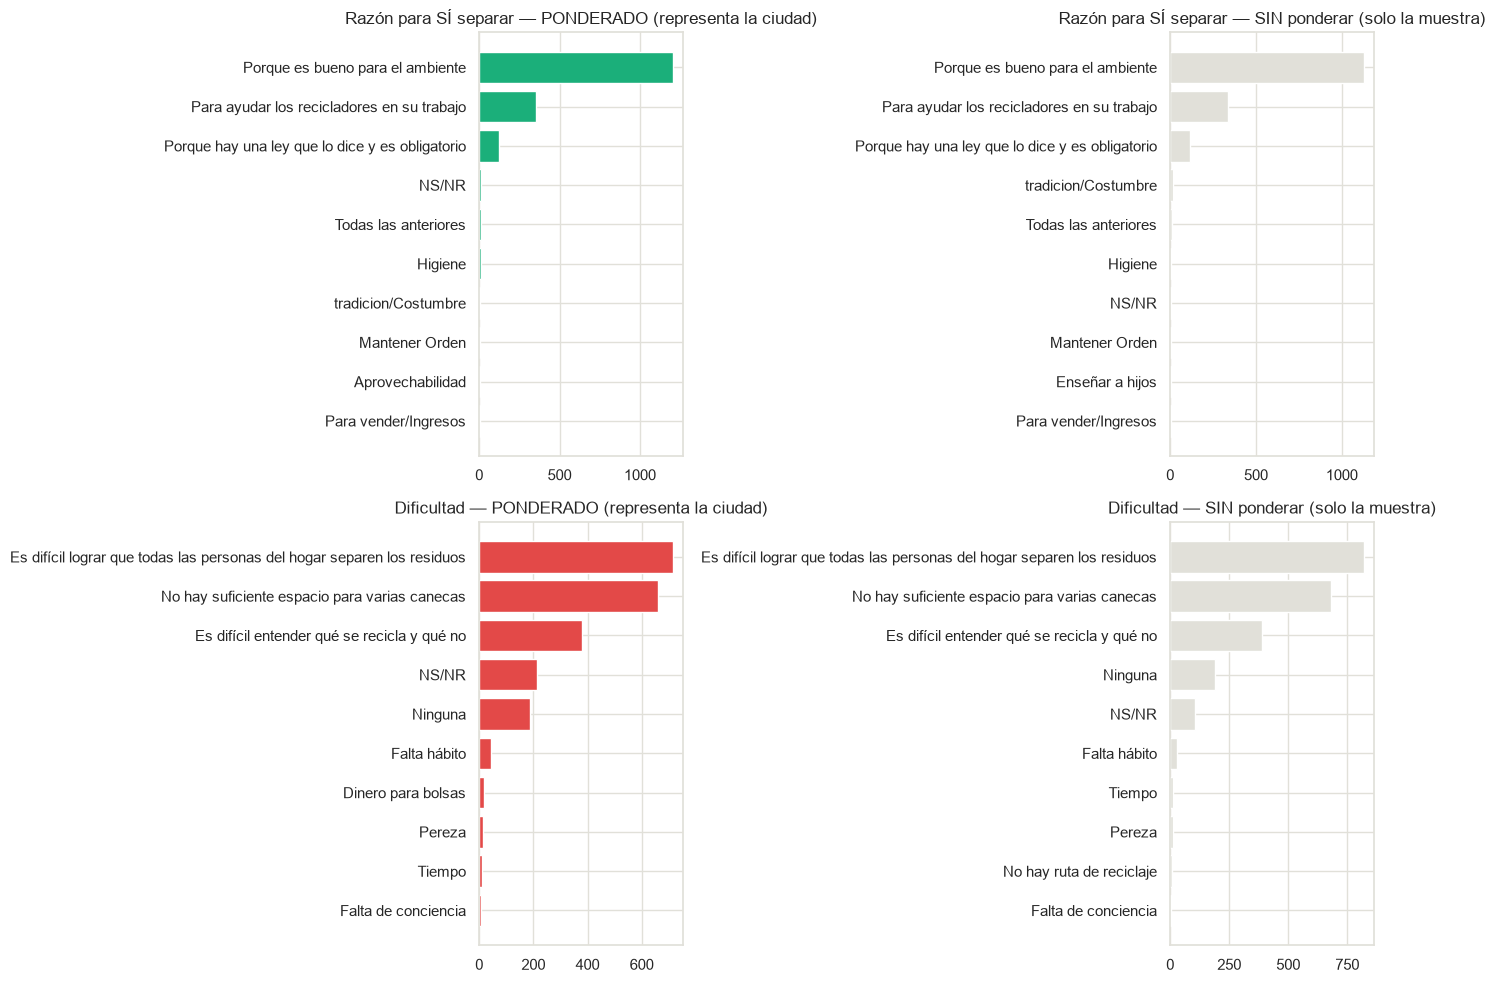

In [6]:
col_separa = col_like(df_eca, "separa sus residuos")
col_razon = col_like(df_eca, "principal razon")
col_dificultad = col_like(df_eca, "principal dificultad")
col_estrato_eca = col_like(df_eca, "estrato")
col_ponderador = "PONDERADOR"

df_eca["_peso"] = pd.to_numeric(df_eca[col_ponderador], errors="coerce")


def etiquetar(serie: pd.Series, texto_pregunta_clave: str) -> pd.Series:
    pregunta = next(p for p in diccionario_eca if texto_pregunta_clave in p)
    mapa_codigos = diccionario_eca[pregunta]
    return pd.to_numeric(serie, errors="coerce").map(mapa_codigos)


def conteo_ponderado(etiquetas: pd.Series, pesos: pd.Series, top: int = 10) -> pd.Series:
    return pd.DataFrame({"etiqueta": etiquetas, "peso": pesos}).dropna().groupby("etiqueta")["peso"].sum().sort_values(ascending=False).head(top)


mascara_si_separa = pd.to_numeric(df_eca[col_separa], errors="coerce") == 1
razon_si_separa = etiquetar(df_eca.loc[mascara_si_separa, col_razon], "principal raz")
dificultad_todos = etiquetar(df_eca[col_dificultad], "principal dificultad")

conteo_razon_ponderado = conteo_ponderado(razon_si_separa, df_eca.loc[mascara_si_separa, "_peso"])
conteo_dificultad_ponderado = conteo_ponderado(dificultad_todos, df_eca["_peso"])
conteo_razon_crudo = razon_si_separa.value_counts().head(10)
conteo_dificultad_crudo = dificultad_todos.value_counts().head(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].barh(conteo_razon_ponderado.index[::-1], conteo_razon_ponderado.values[::-1], color=eda.PALETA_CATEGORICA[1])
axes[0, 0].set_title("Razón para SÍ separar — PONDERADO (representa la ciudad)")
axes[0, 1].barh(conteo_razon_crudo.index[::-1], conteo_razon_crudo.values[::-1], color=eda.COLOR_GRID)
axes[0, 1].set_title("Razón para SÍ separar — SIN ponderar (solo la muestra)")
axes[1, 0].barh(conteo_dificultad_ponderado.index[::-1], conteo_dificultad_ponderado.values[::-1], color=eda.PALETA_CATEGORICA[5])
axes[1, 0].set_title("Dificultad — PONDERADO (representa la ciudad)")
axes[1, 1].barh(conteo_dificultad_crudo.index[::-1], conteo_dificultad_crudo.values[::-1], color=eda.COLOR_GRID)
axes[1, 1].set_title("Dificultad — SIN ponderar (solo la muestra)")
fig.tight_layout()
plt.show()

**Técnica: distribución comparada (violín + puntos), no solo boxplot.** Un boxplot esconde
si la distribución es bimodal o si hay pocos datos sosteniendo un grupo — el violín con los
puntos superpuestos muestra ambas cosas a la vez. El violín en sí no se pondera (dibuja la forma
de la muestra), pero la prueba de significancia que sigue sí.

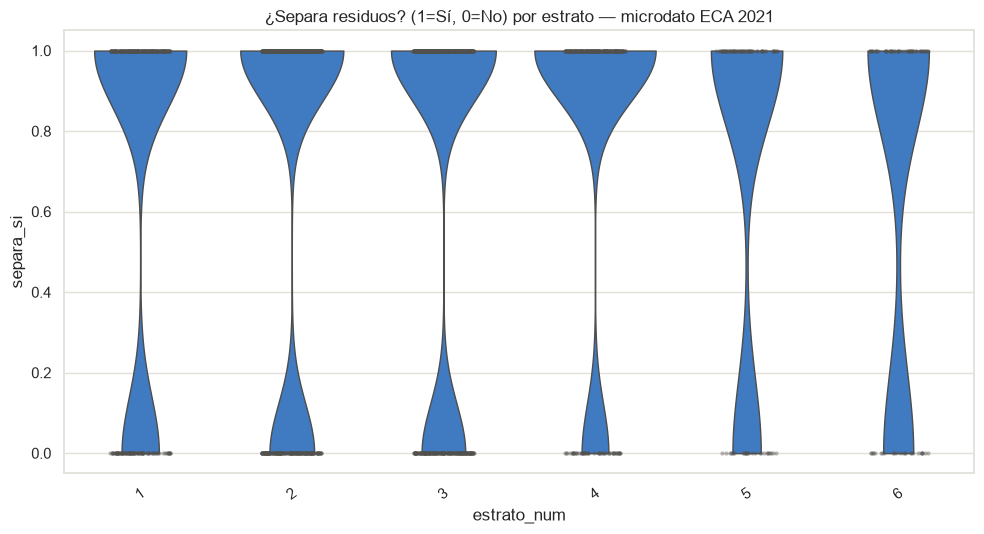

SIN ponderar : chi2=18.3, p=0.0026
PONDERADO    : chi2=14.0, p=0.0156

Nota de honestidad estadística: el chi² ponderado usa sumas de peso muestral como si
fueran conteos — es el ajuste estándar para que la proporción refleje a la población,
pero NO corrige el error estándar por el diseño muestral complejo (conglomerados/estratos
del muestreo original), así que el p-valor ponderado puede ser algo optimista. Para este
EDA es suficiente para ver la DIRECCIÓN y magnitud reales; una tesis que dependa de un
p-valor exacto debería usar un paquete de diseño muestral complejo (ej. R survey / Python samplics).


In [7]:
df_eca_valido = df_eca.copy()
df_eca_valido["estrato_num"] = pd.to_numeric(df_eca_valido[col_estrato_eca], errors="coerce")
df_eca_valido["separa_si"] = (pd.to_numeric(df_eca_valido[col_separa], errors="coerce") == 1).astype(int)
# El código 99 (NS/NR) de estrato no es un estrato real — se excluye antes de comparar grupos.
df_eca_valido = df_eca_valido[df_eca_valido["estrato_num"].between(1, 6)]

fig = eda.graficar_distribucion_comparada(
    df_eca_valido, "separa_si", "estrato_num",
    titulo="¿Separa residuos? (1=Sí, 0=No) por estrato — microdato ECA 2021",
)
plt.show()

resultado_chi2_sin_ponderar = eda.prueba_chi_cuadrado(df_eca_valido, "estrato_num", "separa_si")

# Chi-cuadrado PONDERADO: la tabla de contingencia se construye sumando el peso muestral de cada
# combinación estrato×separa (no contando filas), antes de aplicar la prueba — así la prueba
# refleja la población representada, no la composición accidental de la muestra.
from scipy import stats as _stats
tabla_ponderada = pd.pivot_table(df_eca_valido, index="estrato_num", columns="separa_si", values="_peso", aggfunc="sum", fill_value=0)
chi2_ponderado, p_ponderado, gl_ponderado, _ = _stats.chi2_contingency(tabla_ponderada)

print(f"SIN ponderar : chi2={resultado_chi2_sin_ponderar['chi2']:.1f}, p={resultado_chi2_sin_ponderar['p_valor']:.4f}")
print(f"PONDERADO    : chi2={chi2_ponderado:.1f}, p={p_ponderado:.4f}")
print()
print("Nota de honestidad estadística: el chi² ponderado usa sumas de peso muestral como si")
print("fueran conteos — es el ajuste estándar para que la proporción refleje a la población,")
print("pero NO corrige el error estándar por el diseño muestral complejo (conglomerados/estratos")
print("del muestreo original), así que el p-valor ponderado puede ser algo optimista. Para este")
print("EDA es suficiente para ver la DIRECCIÓN y magnitud reales; una tesis que dependa de un")
print("p-valor exacto debería usar un paquete de diseño muestral complejo (ej. R survey / Python samplics).")

### ¿Y la edad? — variable encontrada en auditoría, faltaba usarla

La ECA 2021 sí trae edad individual (`¿Cuántos años cumplidos tiene usted? (Mayor)`, cobertura
completa, 18-88 años) — a diferencia de EM2021, donde se buscó y no se encontró una columna de
edad ya extraída. Se prueba aquí, ponderada, junto con estrato: ¿la edad influye en si la
persona separa, controlando por estrato?

In [8]:
col_edad_eca = col_like(df_eca, "cuantos anos cumplidos", "mayor")
df_eca_valido["edad"] = pd.to_numeric(df_eca[col_edad_eca], errors="coerce")

import statsmodels.api as sm

X_edad = sm.add_constant(df_eca_valido[["estrato_num", "edad"]])
y_edad = df_eca_valido["separa_si"]
modelo_edad_ponderado = sm.GLM(y_edad, X_edad, family=sm.families.Binomial(), freq_weights=df_eca_valido["_peso"]).fit()

resumen_edad = pd.DataFrame({
    "odds_ratio": np.exp(modelo_edad_ponderado.params),
    "p_valor": modelo_edad_ponderado.pvalues,
}).drop(index="const")
print(f"n = {int(modelo_edad_ponderado.nobs):,} (ECA, ponderado por PONDERADOR)")
resumen_edad.round(4)

n = 2,266 (ECA, ponderado por PONDERADOR)


,odds_ratio,p_valor
estrato_num,1.1675,0.0001
edad,1.0409,0.0000


**Lectura:** si el odds ratio de `edad` es cercano a 1 y su p-valor no es significativo,
la edad NO parece influir de forma importante en si la persona separa, una vez se tiene en
cuenta el estrato — sería un hallazgo tan válido como uno positivo: "no influye" también es una
respuesta real a la pregunta, no un vacío.

---
## 2. Estructura y eficiencia de la recolección y la logística

**Técnica: series múltiples con orden categórico fijo.** Cada ASE mantiene siempre el mismo
color en todos los gráficos de esta sección — así se puede seguir "Promoambiental" con la vista
sin releer la leyenda cada vez. Es la primera vez que este proyecto tiene una serie temporal real
de recolección por operador (antes solo existía un escalar agregado de ciudad).

Meses con datos por año (cobertura real, no siempre 12):
anio
2018     3
2019     5
2020     1
2021     9
2022    11
2023     9
2024    12
2025    12
2026     4
Name: mes, dtype: int64


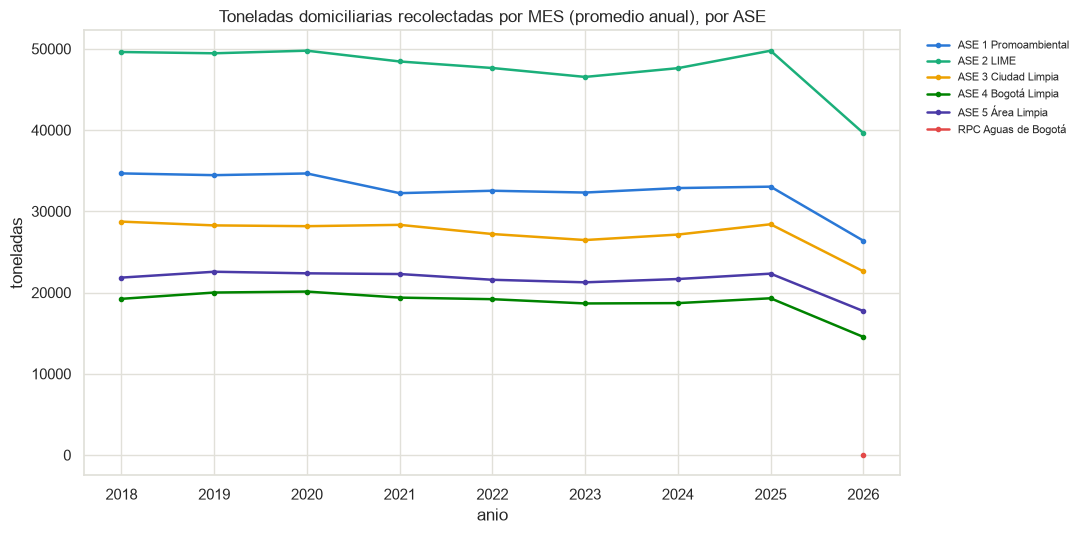

In [9]:
df_rbl_comparable = df_rbl[df_rbl["esquema"] == "ase_2018+"]

# Se usa el PROMEDIO mensual, no la suma anual: 2020 y 2026 no tienen los 12 meses cubiertos
# (varios archivos de 2020 no se pudieron leer por delimitador inconsistente, y 2026 va
# corrido hasta junio) — sumar un año incompleto se vería como una caída real que no lo es.
# El promedio mensual sí es comparable entre años con distinta cantidad de meses disponibles.
meses_por_anio = df_rbl_comparable.groupby("anio")["mes"].nunique()
print("Meses con datos por año (cobertura real, no siempre 12):")
print(meses_por_anio)

df_rbl_domiciliario = (
    df_rbl_comparable[df_rbl_comparable["tipo_residuo"] == "domiciliario"]
    .groupby(["anio", "operador"], as_index=False)["toneladas"].mean()
)
fig = eda.graficar_series_multiples(
    df_rbl_domiciliario, "anio", "toneladas", "operador",
    titulo="Toneladas domiciliarias recolectadas por MES (promedio anual), por ASE",
    orden_hue=sorted(df_rbl_domiciliario["operador"].unique()),
)
plt.show()

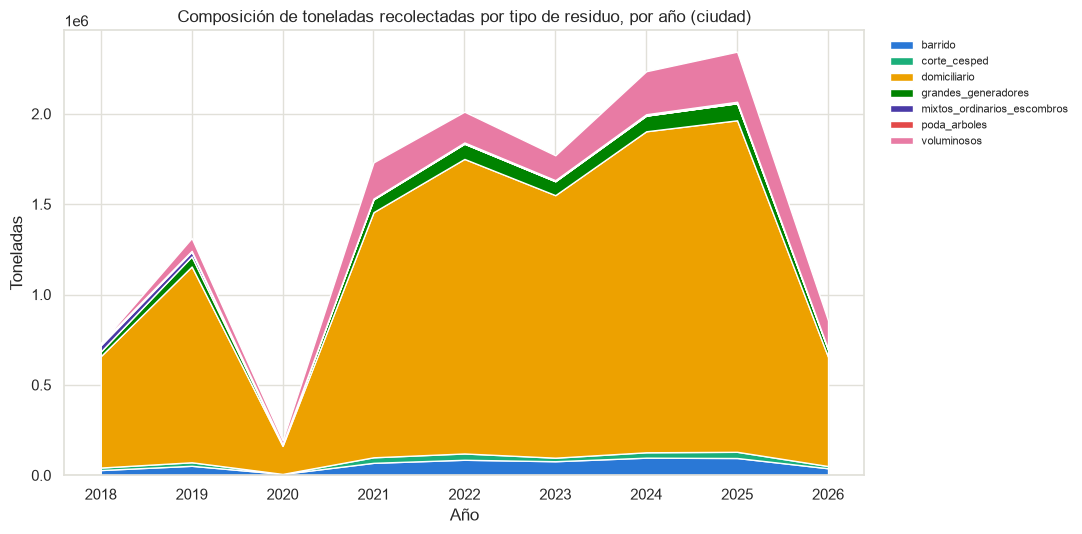

In [10]:
df_rbl_tipo_anual = (
    df_rbl_comparable.groupby(["anio", "tipo_residuo"], as_index=False)["toneladas"].sum()
)
pivote_tipo = df_rbl_tipo_anual.pivot(index="anio", columns="tipo_residuo", values="toneladas").fillna(0)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.stackplot(pivote_tipo.index, pivote_tipo.values.T, labels=pivote_tipo.columns,
             colors=eda.PALETA_CATEGORICA[:len(pivote_tipo.columns)])
ax.set_title("Composición de toneladas recolectadas por tipo de residuo, por año (ciudad)")
ax.set_xlabel("Año")
ax.set_ylabel("Toneladas")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

### Geoespacial: macrorutas reales (primera vez que este proyecto tiene la estructura
operativa real, no solo toneladas agregadas)

**Técnica: mapa categórico** (color = identidad, no magnitud) — cada color es una frecuencia de
recolección distinta, en el orden fijo de la paleta.

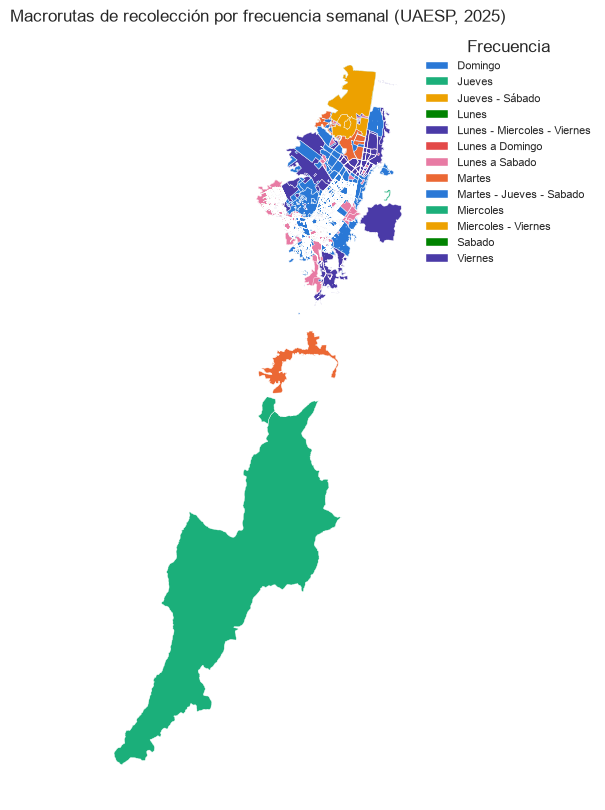

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
frecuencias = sorted(gdf_macrorutas_recoleccion["NOMFRECUEN"].dropna().unique())
colores = {f: eda.PALETA_CATEGORICA[i % len(eda.PALETA_CATEGORICA)] for i, f in enumerate(frecuencias)}
for frecuencia, grupo in gdf_macrorutas_recoleccion.groupby("NOMFRECUEN"):
    grupo.plot(ax=ax, color=colores.get(frecuencia, "#999999"), edgecolor="white",
               linewidth=0.3, label=frecuencia)
ax.set_title("Macrorutas de recolección por frecuencia semanal (UAESP, 2025)")
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left", fontsize=8, frameon=False, title="Frecuencia")
plt.show()

### Geoespacial avanzado: puntos críticos por UPZ, en 4 cortes del tiempo

**Técnica: pequeños múltiplos con la MISMA escala de color en los 4 mapas** — condición
indispensable para que comparar entre paneles sea válido. Se reutiliza
`geoespacial.join_puntos_a_upz` (ya construido en la Fase 1) para asignar cada punto crítico a su
UPZ por coordenadas.

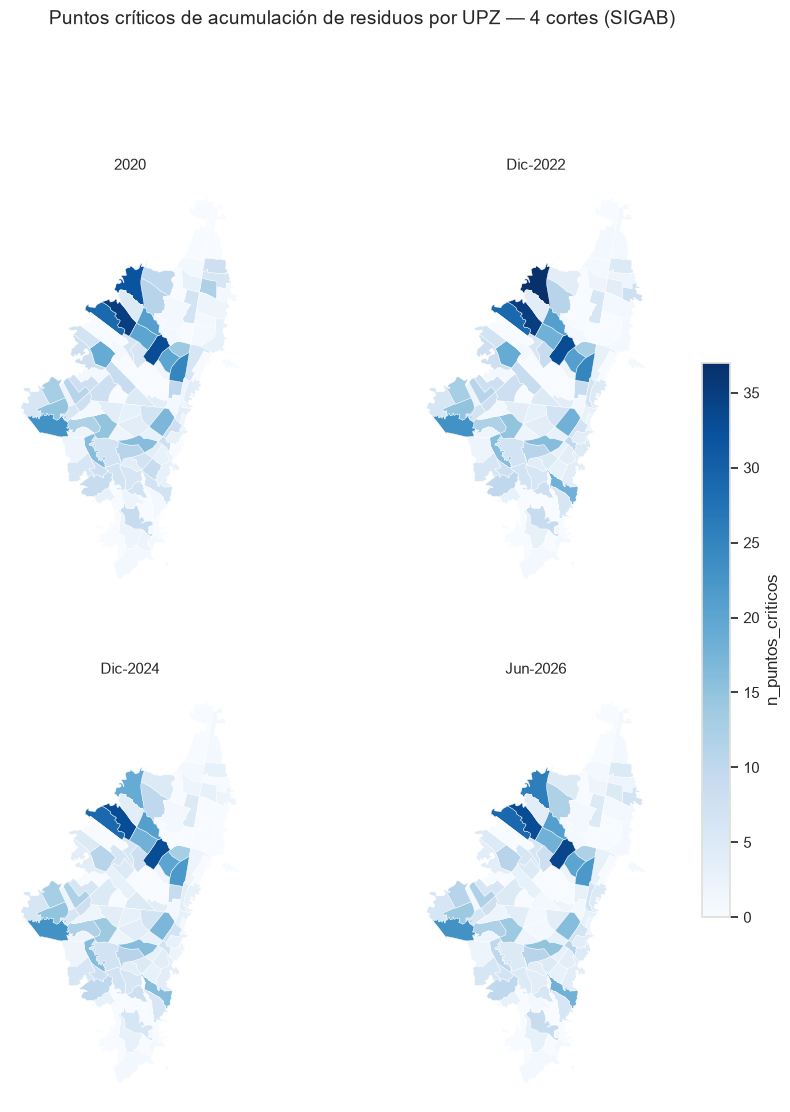

In [12]:
gdfs_puntos_criticos_por_upz = {}
for etiqueta, snap in [("2020", "sigab_2020"), ("Dic-2022", "sigab_2022_diciembre"),
                        ("Dic-2024", "sigab_2024_diciembre"), ("Jun-2026", "sigab_2026_junio")]:
    puntos = sigab[snap].get("puntos_criticos")
    if puntos is None or "LONG" not in "".join(puntos.columns).upper():
        continue
    col_lon = [c for c in puntos.columns if "LONG" in c.upper()][0]
    col_lat = [c for c in puntos.columns if "LAT" in c.upper()][0]
    gdf_puntos = carga_datos.puntos_desde_lonlat(puntos, col_lon, col_lat)
    gdf_puntos_upz = geoespacial.join_puntos_a_upz(gdf_puntos, gdf_upz)
    conteo = gdf_puntos_upz.groupby("CODIGO_UPZ").size().rename("n_puntos_criticos").reset_index()
    gdfs_puntos_criticos_por_upz[etiqueta] = gdf_upz.merge(conteo, on="CODIGO_UPZ", how="left").fillna({"n_puntos_criticos": 0})

if gdfs_puntos_criticos_por_upz:
    fig = eda.graficar_pequenos_multiplos_mapa(
        gdfs_puntos_criticos_por_upz, "n_puntos_criticos",
        "Puntos críticos de acumulación de residuos por UPZ — 4 cortes (SIGAB)",
    )
    plt.show()

**Técnica: mapa bivariado.** ¿Los puntos críticos se concentran donde el estrato es más
bajo? En vez de dos mapas secuenciales lado a lado (difícil de comparar visualmente), se combinan
las dos variables en una sola cuadrícula de color 3x3.

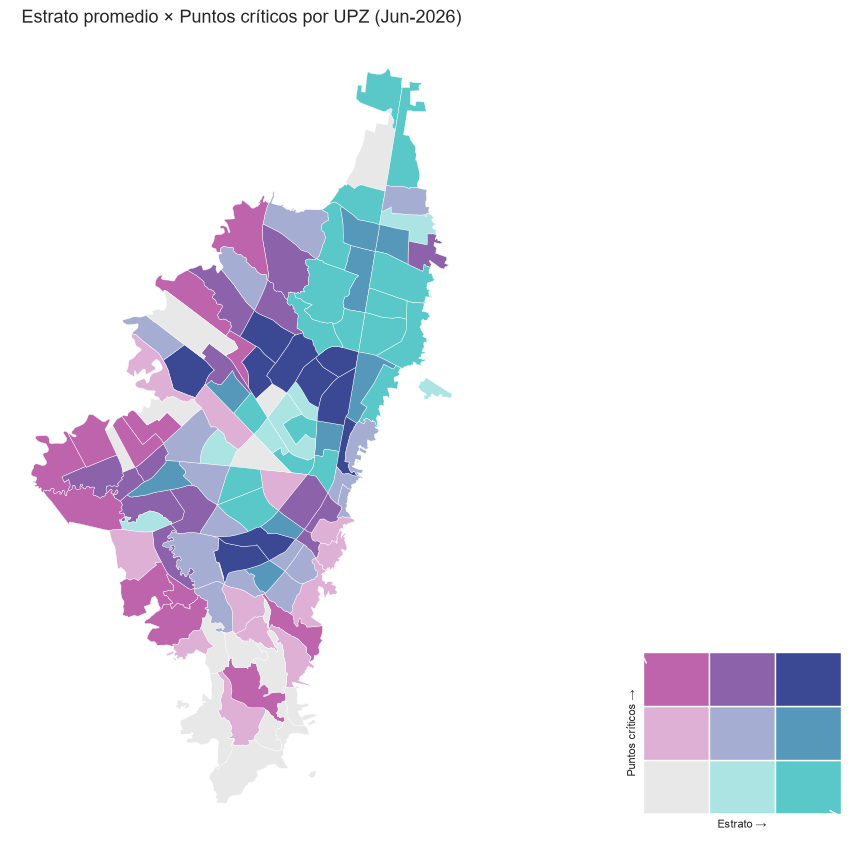

In [13]:
if "Jun-2026" in gdfs_puntos_criticos_por_upz:
    gdf_bivariado = gdfs_puntos_criticos_por_upz["Jun-2026"].merge(
        df_modelo_actual[["CODIGO_UPZ", "estrato_promedio"]], on="CODIGO_UPZ", how="left"
    )
    fig = eda.graficar_mapa_bivariado(
        gdf_bivariado, "estrato_promedio", "n_puntos_criticos",
        titulo="Estrato promedio × Puntos críticos por UPZ (Jun-2026)",
        etiqueta_x="Estrato →", etiqueta_y="Puntos críticos →",
    )
    plt.show()

---
## 3. Capacidad y formalización de los recicladores de oficio

Antes de la Fase 2, esta categoría solo tenía conteo y edad promedio por localidad. El RURO
oficial trae, por primera vez, indicadores reales de formalización.

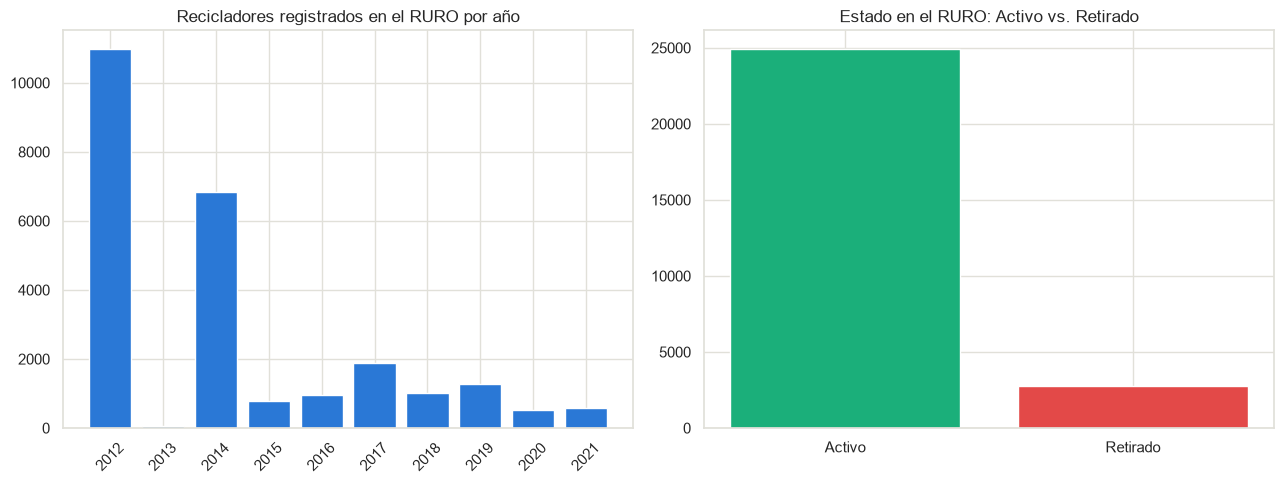

% de recicladores registrados que están Activos: 89.9%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
serie = ruro_bloques["serie_anual"]
axes[0].bar(serie["anio"].astype(str), serie["n_recicladores"], color=eda.PALETA_CATEGORICA[0])
axes[0].set_title("Recicladores registrados en el RURO por año")
axes[0].tick_params(axis="x", rotation=45)

estado = ruro_bloques["estado"]
axes[1].bar(estado["estado"], estado["cantidad"], color=[eda.PALETA_CATEGORICA[1], eda.PALETA_CATEGORICA[5]])
axes[1].set_title("Estado en el RURO: Activo vs. Retirado")
fig.tight_layout()
plt.show()

pct_activos = estado.set_index("estado")["cantidad"]["Activo"] / estado["cantidad"].sum() * 100
print(f"% de recicladores registrados que están Activos: {pct_activos:.1f}%")

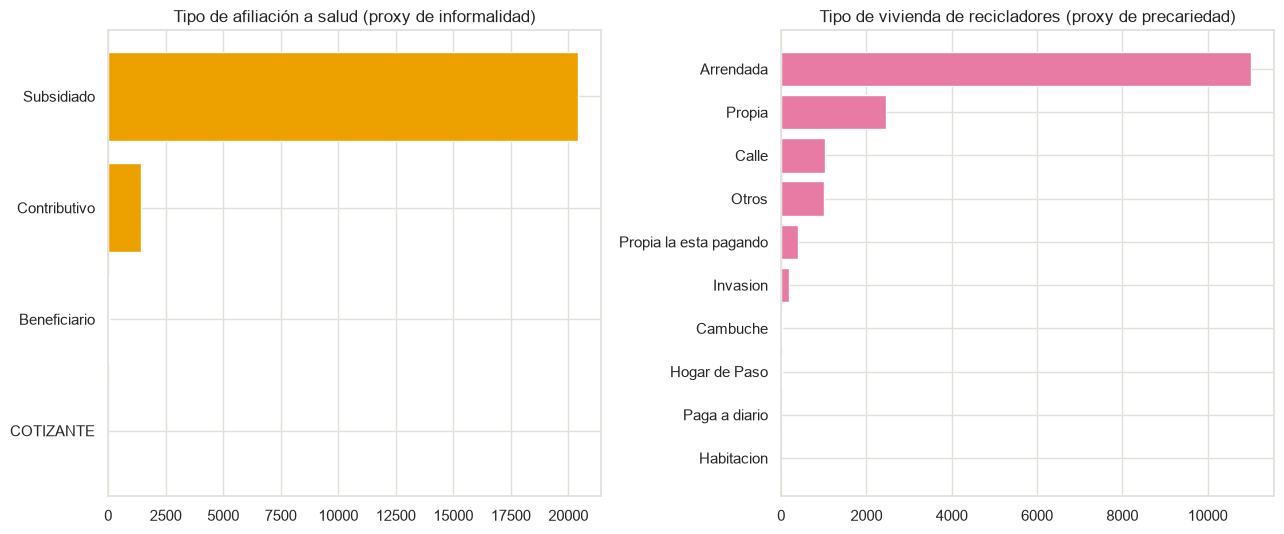

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
salud = ruro_bloques["nivel_salud"].sort_values("cantidad", ascending=True)
axes[0].barh(salud["tipo_afiliacion"], salud["cantidad"], color=eda.PALETA_CATEGORICA[2])
axes[0].set_title("Tipo de afiliación a salud (proxy de informalidad)")

vivienda = ruro_bloques["tipo_vivienda"].sort_values("cantidad", ascending=True)
axes[1].barh(vivienda["tipo_vivienda"], vivienda["cantidad"], color=eda.PALETA_CATEGORICA[6])
axes[1].set_title("Tipo de vivienda de recicladores (proxy de precariedad)")
fig.tight_layout()
plt.show()

### RURO 2022 por localidad: primera vez con tasa de formalización territorial (afiliación ARL)

**Técnica: barra horizontal ordenada** — cuando el interés es comparar 20 categorías (las
localidades), una barra horizontal ordenada de mayor a menor es más legible que un mapa con muy
pocos polígonos (solo 19-20 localidades urbanas) o que una leyenda categórica larga.

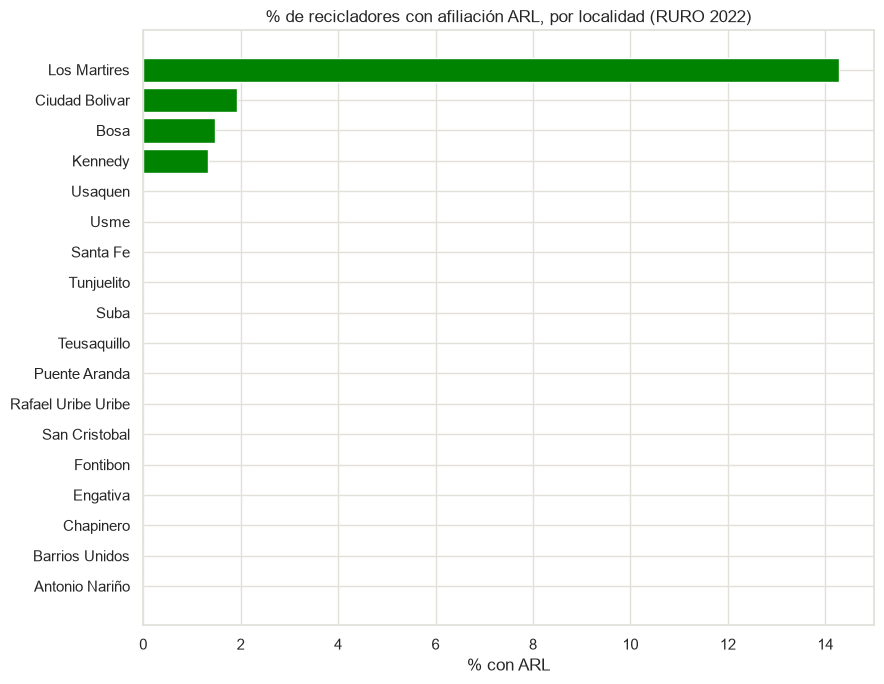

In [16]:
formalizacion_localidad = (
    df_ruro_2022.groupby("Nom_Localidad")
    .agg(recicladores=("#Recicladores", "sum"), con_arl=("#ARL", "sum"))
    .assign(pct_arl=lambda d: 100 * d["con_arl"] / d["recicladores"])
    .sort_values("pct_arl", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(formalizacion_localidad.index, formalizacion_localidad["pct_arl"], color=eda.PALETA_CATEGORICA[3])
ax.set_title("% de recicladores con afiliación ARL, por localidad (RURO 2022)")
ax.set_xlabel("% con ARL")
fig.tight_layout()
plt.show()

---
## 4. Gobernanza institucional y coordinación intersectorial

Es la categoría con menos datos cuantitativos del proyecto (documentado en
`Recoleccion_Datos_Fase2.md`). Se usan las PQRS de aseo (dentro de SIGAB) como el único proxy
disponible, comparando los 2 snapshots que sí tienen este archivo completo (2020 y dic-2022).

**Técnica: gráfico de pendiente (slope chart).** Para comparar un mismo conjunto de categorías
en 2 momentos del tiempo, un gráfico de pendiente muestra la dirección del cambio de un vistazo
— mejor que dos barras separadas, porque el ojo sigue la línea, no dos alturas distintas.

**Nota de calidad de dato, encontrada al construir este gráfico:** cada archivo
`pqrsxlocalidad.csv` de SIGAB no es un corte de un solo mes — es un **acumulado histórico
mensual** desde febrero de 2018 hasta el mes del snapshot (el de dic-2022 trae 59 meses
distintos en la columna `PERIODO`, formato AAMM). Sumar todo el archivo habría mezclado ~5 años
de PQRS en un solo número. Aquí se toma solo el **último mes disponible** de cada snapshot, para
que la comparación sea entre dos puntos reales en el tiempo, no entre dos acumulados de tamaño
distinto.

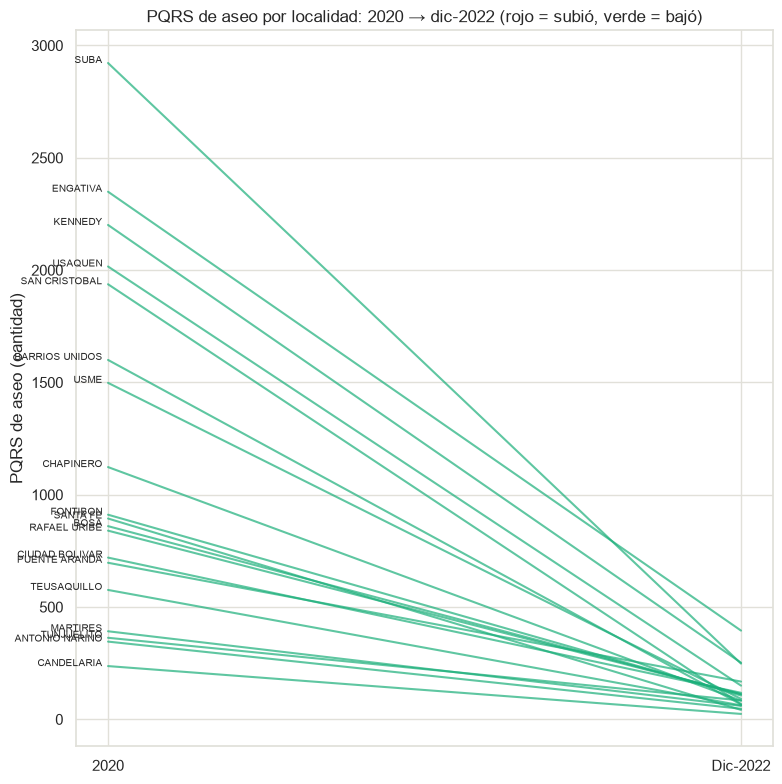

In [17]:
def pqrs_ultimo_mes(snapshot):
    df = sigab[snapshot]["pqrs_por_localidad"]
    return df[df["PERIODO"] == df["PERIODO"].max()].groupby("LOCALIDAD")["CANTIDAD"].sum()

pqrs_2020 = pqrs_ultimo_mes("sigab_2020")
pqrs_2022 = pqrs_ultimo_mes("sigab_2022_diciembre")
comparacion_pqrs = pd.DataFrame({"2020": pqrs_2020, "Dic-2022": pqrs_2022}).dropna().sort_values("2020")

fig, ax = plt.subplots(figsize=(8, 8))
for i, (localidad, fila) in enumerate(comparacion_pqrs.iterrows()):
    color = eda.PALETA_CATEGORICA[5] if fila["Dic-2022"] > fila["2020"] else eda.PALETA_CATEGORICA[1]
    ax.plot([0, 1], [fila["2020"], fila["Dic-2022"]], color=color, alpha=0.7, linewidth=1.5)
    ax.annotate(localidad, (0, fila["2020"]), fontsize=7, ha="right", xytext=(-4, 0), textcoords="offset points")
ax.set_xticks([0, 1])
ax.set_xticklabels(["2020", "Dic-2022"])
ax.set_ylabel("PQRS de aseo (cantidad)")
ax.set_title("PQRS de aseo por localidad: 2020 → dic-2022 (rojo = subió, verde = bajó)")
fig.tight_layout()
plt.show()

---
## 5. Incentivos económicos (sin condiciones de mercado de reciclables — exclusión vigente)

La tabla de tarifas de diciembre 2025 (`Tarifas_ASE3_202512.pdf`, ya descargada en la Fase 2) da
el factor real de subsidio/contribución por estrato. Aquí se combina con la composición real de
estratos por UPZ (`df_modelo`) para estimar qué tan expuesta está cada UPZ al incentivo — un
cruce que no se podía hacer antes porque solo existía un escalar agregado de ciudad.

**Nota de fuente:** esta tabla es la tarifa oficial publicada por Ciudad Limpia Bogotá S.A. bajo
vigilancia de la Superintendencia de Servicios Públicos — un dato público verificable.

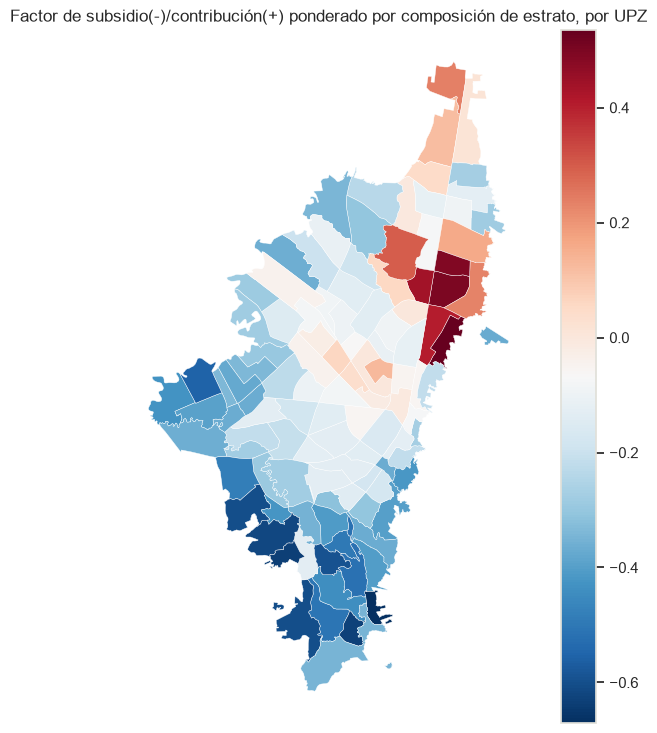

In [18]:
# Factor de subsidio(-)/contribución(+) por estrato, tal como aparece en Tarifas_ASE3_202512.pdf
factor_subsidio_por_estrato = {1: -0.70, 2: -0.40, 3: -0.15, 4: 0.0, 5: 0.50, 6: 0.60}

df_incentivo_upz = df_modelo_actual[["CODIGO_UPZ", "pct_e1", "pct_e2", "pct_e3", "pct_e4", "pct_e5", "pct_e6"]].copy()
df_incentivo_upz["factor_incentivo_ponderado"] = sum(
    df_incentivo_upz[f"pct_e{estrato}"] / 100 * factor
    for estrato, factor in factor_subsidio_por_estrato.items()
)

gdf_incentivo = gdf_upz.merge(df_incentivo_upz, on="CODIGO_UPZ", how="inner")
fig = eda.graficar_mapa_coropletico(
    gdf_incentivo, "factor_incentivo_ponderado",
    "Factor de subsidio(-)/contribución(+) ponderado por composición de estrato, por UPZ",
    cmap=eda.CMAP_DIVERGENTE,
)
plt.show()

---
## 6. Interacciones entre actores — el corazón de la pregunta de investigación

Todo lo anterior describe una categoría a la vez. Esta sección cruza categorías, que es
literalmente lo que pregunta el proyecto de grado: *"cómo las interacciones entre los actores...
generan las dinámicas emergentes que condicionan el aprovechamiento"*.

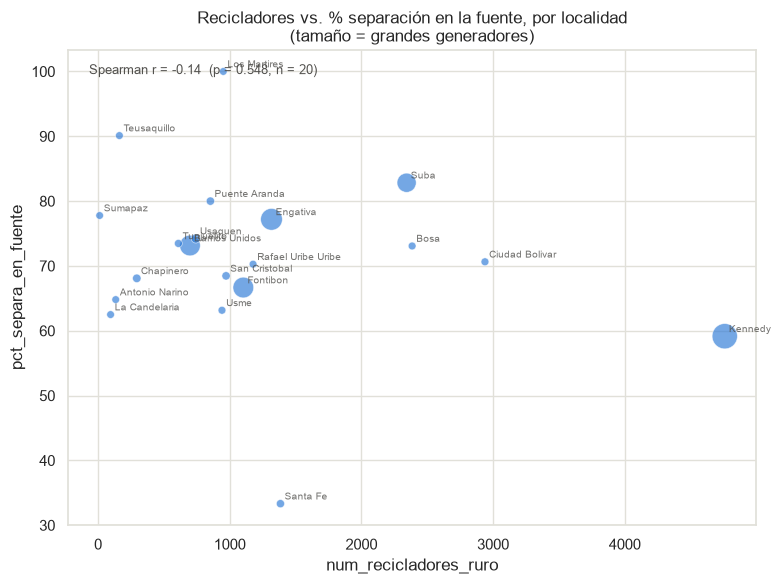

In [19]:
fig = eda.graficar_dispersion_actores(
    df_actores, x="num_recicladores_ruro", y="pct_separa_en_fuente",
    tamano="num_grandes_generadores", etiqueta="localidad",
    titulo="Recicladores vs. % separación en la fuente, por localidad\n(tamaño = grandes generadores)",
)
plt.show()

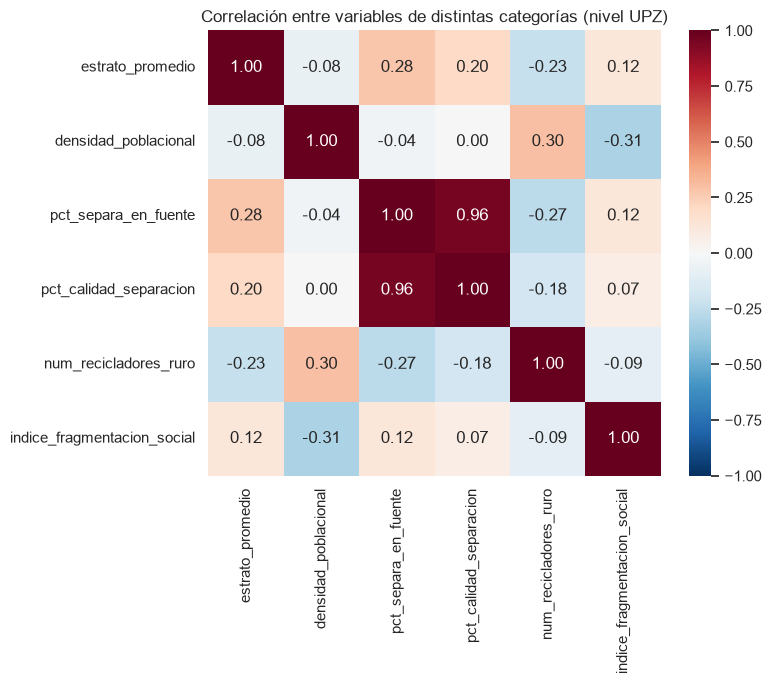

In [20]:
columnas_interaccion = [
    "estrato_promedio", "densidad_poblacional", "pct_separa_en_fuente",
    "pct_calidad_separacion", "num_recicladores_ruro", "indice_fragmentacion_social",
]
fig, corr = eda.graficar_correlacion(
    df_modelo_actual, columnas_interaccion,
    titulo="Correlación entre variables de distintas categorías (nivel UPZ)",
)
plt.show()

### Evidencia para la discrepancia de actores (4 vs. 5) — `Analisis_Variables_Negocio.md` §2.1

El proyecto de grado formal declara 4 actores; el notebook original y `Diseno_ABM.md` declaran 5,
separando "puntos limpios/infraestructura" como actor propio. La pregunta empírica: **¿varía
mucho la infraestructura entre UPZ, o es prácticamente uniforme?** Si varía mucho, apoya tratarla
como mecanismo propio; si es uniforme, apoya la simplificación a 4 actores.

In [21]:
if gdfs_puntos_criticos_por_upz:
    valores = gdfs_puntos_criticos_por_upz["Jun-2026"]["n_puntos_criticos"]
    coef_variacion = valores.std() / valores.mean() if valores.mean() > 0 else float("nan")
    print(f"Coeficiente de variación de puntos críticos entre UPZ: {coef_variacion:.2f}")
    print("(>1 sugiere variación territorial fuerte → apoya tratar infraestructura como mecanismo propio;")
    print(" <0.5 sugiere una condición más uniforme → apoya la simplificación a 4 actores)")

Coeficiente de variación de puntos críticos entre UPZ: 1.19
(>1 sugiere variación territorial fuerte → apoya tratar infraestructura como mecanismo propio;
 <0.5 sugiere una condición más uniforme → apoya la simplificación a 4 actores)


---
## 7. Tabla de hallazgos — los 3 criterios de `Plan_EDA.md` §5

Para que la elección de variables del ABM (próxima fase) sea trazable a evidencia y no a
preferencia, cada categoría se resume aquí con: relevancia estadística (¿se vio una relación en
este EDA?), relevancia teórica (¿está conectada al marco conceptual?), y calidad del dato (¿a qué
nivel de agregación es real, qué tan grande es la muestra?).

| Categoría | Relevancia estadística (este EDA) | Relevancia teórica | Calidad del dato |
|---|---|---|---|
| 1. Separación | Chi² estrato×separación (ver arriba) | Núcleo de la hipótesis | Microdato individual (n=2,282), pero localidad, no UPZ |
| 2. Recolección/logística | Composición de tipo varía por año | Mecanismo de eficiencia formal | RBL: serie real 2018-2026; SIGAB: 4 cortes, 2 con PQRS completo |
| 3. Recicladores | % ARL varía fuerte por localidad | Mecanismo de coordinación informal | RURO 2022: agrupado, no individual; oficial 2012-2021: ciudad, no territorial |
| 4. Gobernanza | PQRS cambia de dirección por localidad 2020→2022 | Mecanismo institucional | Solo 2 snapshots completos de 4; sin serie larga |
| 5. Incentivos económicos | Factor de subsidio varía con composición de estrato por UPZ | Mecanismo económico | Solo 1 ASE (de 5) con tarifa real descargada |
| 6. Socio-demográfico | Base de todos los cruces anteriores | Variables de control | La mejor cubierta — manzana, real |


---
## 8. Análisis multivariado con la Encuesta Multipropósito 2021 — ¿qué influye realmente, controlando por lo demás?

**Aclaración necesaria (dos encuestas distintas, no una):** hasta aquí este notebook usó la
**Encuesta de Cultura Ambiental (ECA 2021)** para las preguntas de comportamiento — es una
encuesta más pequeña (~2,282 personas) y específicamente ambiental. La **Encuesta
Multipropósito (EM 2021)** es una encuesta DISTINTA, mucho más grande (~234,000 hogares de
Bogotá), con variables socioeconómicas detalladas (educación, ingreso, informalidad, tenencia
de vivienda, tamaño del hogar, participación comunitaria) que se extrajeron y documentaron por
tipo en la Fase 2 (`carga_datos.NATURALEZA_COLUMNAS_MULTIPROPOSITO_FASE2`) pero **nunca se
habían analizado** — un hueco real en el EDA hasta esta sección.

**Técnica: regresión logística multivariada, no solo cruces de a dos variables.** Un chi-cuadrado
por variable (como se hizo en la Sección 1 con estrato) no distingue si una variable influye por
sí misma o solo porque está correlacionada con otra (ej. educación y estrato suelen ir juntos).
La regresión logística estima el efecto de cada variable **controlando por todas las demás al
mismo tiempo** — la pregunta correcta para "¿esto influye de verdad?".

**Nota de honestidad metodológica:** esta encuesta es de corte transversal (un solo momento en
el tiempo) — una asociación estadística aquí no prueba causalidad, solo que la relación existe
en los datos observados. Se reporta así, no como causa-efecto.

**Nota sobre edad:** se buscó una variable de edad individual en el diccionario oficial de EM2021
para incluirla aquí y no se encontró una columna de edad de respondente ya extraída en
`COLUMNAS_MULTIPROPOSITO` — la estructura de edad de la población sí está en `df_modelo` (pirámide
demográfica DANE por UPZ), pero no vinculada a nivel individual con la respuesta de separación.
Se deja como hueco explícito, no se inventa una columna.

**Factor de expansión, otra vez — esta vez en EM2021.** La EM2021 trae `FEX_C` (factor de
expansión calibrado), verificado antes de usarlo: suma ~7.84 millones, consistente con
población — no hogares — de Bogotá, así que expande a personas/hogares-equivalentes reales, no
es un número arbitrario. Igual que con la ECA, la regresión se corre **con y sin** este peso
para que se vea el efecto de ponderar, no solo se asuma.

In [22]:
df_em = carga_datos.cargar_multiproposito()


def a_numerico(serie: pd.Series) -> pd.Series:
    return pd.to_numeric(serie.replace("NA", np.nan), errors="coerce")


datos_reg = pd.DataFrame({
    "separa": (df_em["NHCCP38"] == "1").astype(int),
    "estrato": a_numerico(df_em["NVCBP11AA"]),
    "educacion": a_numerico(df_em["NPCHP4"]),
    "log_ingreso": np.log1p(a_numerico(df_em["NPCKP23"]).clip(upper=15_000_000)),
    "informal": a_numerico(df_em["OINFORMAL"]),
    "personas_hogar": a_numerico(df_em["NHCCPCTRL2"]),
    "vivienda_propia": (a_numerico(df_em["NVCBP10"]) == 1).astype(float),  # 1=Casa (proxy simple de tipo/tenencia)
    "participa_ambiental": (df_em["NPCJP1F"] == "1").astype(int),
    "participa_jac": (df_em["NPCJP1I"] == "1").astype(int),
    "peso": a_numerico(df_em["FEX_C"]),
})

# Educación (NPCHP4) e informalidad (OINFORMAL) tienen NA genuino (no aplica / no ocupado, no
# "checkbox sin marcar" como participación) — se excluyen por listwise deletion, documentando
# cuánta muestra se pierde por variable antes de descartarla.
print("Muestra disponible por variable (de", len(datos_reg), "hogares):")
print(datos_reg.notna().sum().sort_values())

datos_reg_completos = datos_reg.dropna()
print(f"\nMuestra final para la regresión (listwise deletion): {len(datos_reg_completos):,} hogares")
print(f"Población representada (suma de FEX_C en esa muestra): {datos_reg_completos['peso'].sum():,.0f}")

Muestra disponible por variable (de 234043 hogares):
log_ingreso             66141
informal               106210
educacion              170306
estrato                234043
separa                 234043
personas_hogar         234043
vivienda_propia        234043
participa_ambiental    234043
participa_jac          234043
peso                   234043
dtype: int64

Muestra final para la regresión (listwise deletion): 60,235 hogares
Población representada (suma de FEX_C en esa muestra): 2,061,804


**Interpretación de la tabla anterior antes de seguir:** educación e ingreso son las
variables con más datos faltantes (por diseño del cuestionario — no todos los miembros del
hogar responden esas preguntas). El modelo se ajusta sobre el subconjunto con las 9 variables
completas — más pequeño que las 234,000 filas totales, pero sigue siendo un n muy superior al
de la ECA 2021.

In [23]:
import statsmodels.api as sm

X = datos_reg_completos.drop(columns=["separa", "peso"])
X = sm.add_constant(X)
y = datos_reg_completos["separa"]
pesos = datos_reg_completos["peso"]

modelo_sin_ponderar = sm.Logit(y, X).fit(disp=0)
# GLM binomial con freq_weights: la aproximación estándar para regresión logística ponderada por
# encuesta cuando no se dispone del diseño muestral completo (conglomerados/estratos originales)
# — ajusta los coeficientes correctamente a la población, pero los errores estándar (y por tanto
# los p-valores) siguen siendo algo optimistas, igual que en el chi² ponderado de la Sección 1.
modelo_ponderado = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=pesos).fit()

tabla_resultados = pd.DataFrame({
    "odds_ratio_sin_ponderar": np.exp(modelo_sin_ponderar.params),
    "odds_ratio_ponderado": np.exp(modelo_ponderado.params),
    "p_valor_ponderado": modelo_ponderado.pvalues,
    "significativo_95pct_ponderado": modelo_ponderado.pvalues < 0.05,
}).drop(index="const").sort_values("p_valor_ponderado")

print(f"n = {int(modelo_ponderado.nobs):,} hogares en la muestra | población representada = {pesos.sum():,.0f}")
tabla_resultados.round(4)

n = 60,235 hogares en la muestra | población representada = 2,061,804


,odds_ratio_sin_ponderar,odds_ratio_ponderado,p_valor_ponderado,significativo_95pct_ponderado
estrato,1.3890,1.3727,0.0000,True
educacion,1.1311,1.1272,0.0000,True
informal,0.8132,0.8505,0.0000,True
personas_hogar,1.1246,1.1306,0.0000,True
vivienda_propia,1.3828,1.3990,0.0000,True
participa_jac,2.0500,2.6280,0.0000,True
participa_ambiental,2.9761,2.3324,0.0000,True
log_ingreso,1.0062,1.0005,0.3273,False


**Técnica: gráfico de odds ratios (forest plot simplificado).** Un odds ratio > 1 significa
que la variable aumenta la probabilidad de separar; < 1, que la disminuye. El color marca si es
estadísticamente significativo al 95% (con el modelo YA ponderado) — así se lee de un vistazo
qué variables sí importan y cuáles no, en vez de solo mirar una tabla de números.

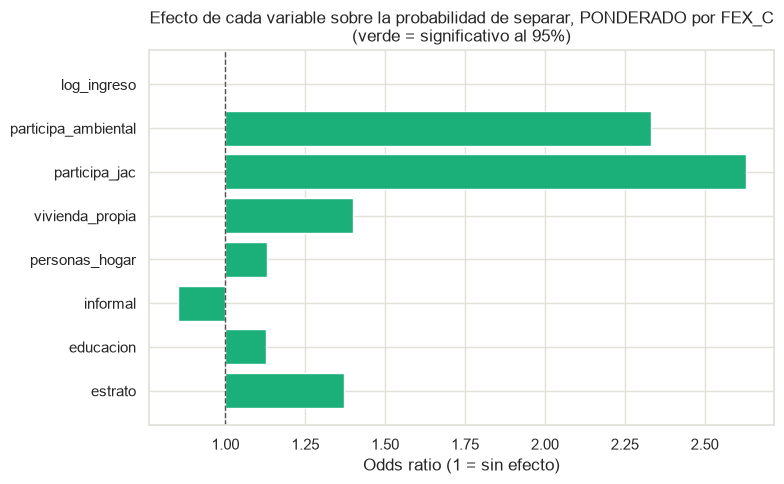

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
colores_forest = [eda.PALETA_CATEGORICA[1] if sig else eda.COLOR_GRID for sig in tabla_resultados["significativo_95pct_ponderado"]]
ax.barh(tabla_resultados.index, tabla_resultados["odds_ratio_ponderado"] - 1, left=1, color=colores_forest)
ax.axvline(1, color=eda.COLOR_TEXTO_SECUNDARIO, linewidth=1, linestyle="--")
ax.set_xlabel("Odds ratio (1 = sin efecto)")
ax.set_title("Efecto de cada variable sobre la probabilidad de separar, PONDERADO por FEX_C\n(verde = significativo al 95%)")
fig.tight_layout()
plt.show()

**¿Cuánto cambió al ponderar?** Última verificación antes de interpretar: comparar el odds
ratio ponderado contra el crudo, variable por variable — si son parecidos, la muestra ya era
razonablemente representativa en estas variables; si difieren mucho, la ponderación estaba
ocultando un sesgo real de la muestra.

In [25]:
tabla_resultados["diferencia_absoluta"] = (tabla_resultados["odds_ratio_ponderado"] - tabla_resultados["odds_ratio_sin_ponderar"]).abs()
tabla_resultados[["odds_ratio_sin_ponderar", "odds_ratio_ponderado", "diferencia_absoluta"]].sort_values("diferencia_absoluta", ascending=False).round(4)

,odds_ratio_sin_ponderar,odds_ratio_ponderado,diferencia_absoluta
participa_ambiental,2.9761,2.3324,0.6437
participa_jac,2.0500,2.6280,0.5780
informal,0.8132,0.8505,0.0372
estrato,1.3890,1.3727,0.0163
vivienda_propia,1.3828,1.3990,0.0162
personas_hogar,1.1246,1.1306,0.0060
log_ingreso,1.0062,1.0005,0.0056
educacion,1.1311,1.1272,0.0039


### Respuesta directa a la pregunta: ¿qué influye realmente?

Con la regresión ya corrida, esta celda arma la respuesta en texto — para no dejar la
interpretación solo al gráfico.

In [26]:
for variable, fila in tabla_resultados.iterrows():
    direccion = "aumenta" if fila["odds_ratio_ponderado"] > 1 else "disminuye"
    significancia = "SÍ es significativo" if fila["significativo_95pct_ponderado"] else "NO es significativo"
    print(f"{variable:22s} | odds ratio (ponderado)={fila['odds_ratio_ponderado']:.3f} | {direccion} la prob. de separar | {significancia} (p={fila['p_valor_ponderado']:.4f})")

estrato                | odds ratio (ponderado)=1.373 | aumenta la prob. de separar | SÍ es significativo (p=0.0000)
educacion              | odds ratio (ponderado)=1.127 | aumenta la prob. de separar | SÍ es significativo (p=0.0000)
informal               | odds ratio (ponderado)=0.850 | disminuye la prob. de separar | SÍ es significativo (p=0.0000)
personas_hogar         | odds ratio (ponderado)=1.131 | aumenta la prob. de separar | SÍ es significativo (p=0.0000)
vivienda_propia        | odds ratio (ponderado)=1.399 | aumenta la prob. de separar | SÍ es significativo (p=0.0000)
participa_jac          | odds ratio (ponderado)=2.628 | aumenta la prob. de separar | SÍ es significativo (p=0.0000)
participa_ambiental    | odds ratio (ponderado)=2.332 | aumenta la prob. de separar | SÍ es significativo (p=0.0000)
log_ingreso            | odds ratio (ponderado)=1.001 | aumenta la prob. de separar | NO es significativo (p=0.3273)


---
## 9. Auditoría perfeccionista: las variables de EM2021 que quedaban "extraídas pero sin analizar"

La auditoría completa (`Auditoria_Completa_Datos_Limpieza_EDA.md`) marcó varias columnas de
`COLUMNAS_MULTIPROPOSITO` como "🟡/⚪ extraídas, no analizadas todavía". Esta sección cierra ese
pendiente: se amplía la regresión de la Sección 8 con las variables restantes que tienen
suficiente varianza y relevancia teórica, y se analizan por separado dos variables que no encajan
como predictor binario simple (`NHCCP37`, la forma de eliminar la basura, y la percepción de
cambio `NHCLP9C/E/F`).

**Qué se dejó fuera del modelo ampliado, y por qué (honesto, no se esconde):**
- `NVCBP11D` (acceso a recolección formal): 98.8% de los hogares respondió "Sí" — casi no hay
  variación que explicar, incluirla no aportaría información real.
- `NVCBP9` (negocio en la vivienda): solo 4% "Sí" — muy poca varianza, y sin relación teórica
  directa con separación de residuos.
- `NPCKP17` (posición ocupacional): ya está representada, de forma más simple y sin perder
  información relevante, por `informal` (`OINFORMAL`).

In [27]:
datos_reg_v2 = pd.DataFrame({
    "separa": (df_em["NHCCP38"] == "1").astype(int),
    "estrato": a_numerico(df_em["NVCBP11AA"]),
    "educacion": a_numerico(df_em["NPCHP4"]),
    "log_ingreso": np.log1p(a_numerico(df_em["NPCKP23"]).clip(upper=15_000_000)),
    "informal": a_numerico(df_em["OINFORMAL"]),
    "personas_hogar": a_numerico(df_em["NHCCPCTRL2"]),
    "vivienda_propia": (a_numerico(df_em["NVCBP10"]) == 1).astype(float),
    "participa_ambiental": (df_em["NPCJP1F"] == "1").astype(int),
    "participa_jac": (df_em["NPCJP1I"] == "1").astype(int),
    # --- variables nuevas de esta sección ---
    "se_considera_pobre": (a_numerico(df_em["NHCLP11"]) == 1).astype(float),
    "vive_en_conjunto": (a_numerico(df_em["NVCBP4"]) == 1).astype(float),
    "cerca_de_basureros": (a_numerico(df_em["NVCBP14B"]) == 1).astype(float),
    "entorno_disposicion_inadecuada": (a_numerico(df_em["NVCBP15F"]) == 1).astype(float),
    "ingresos_alcanzan": a_numerico(df_em["NHCLP10"]),  # 1=No alcanzan, 2=Alcanzan justo, 3=Cubren más
    "peso": a_numerico(df_em["FEX_C"]),
})

datos_reg_v2_completos = datos_reg_v2.dropna()
print(f"Muestra final (13 predictores, listwise deletion): {len(datos_reg_v2_completos):,} hogares")
print(f"Población representada: {datos_reg_v2_completos['peso'].sum():,.0f}")

X_v2 = sm.add_constant(datos_reg_v2_completos.drop(columns=["separa", "peso"]))
y_v2 = datos_reg_v2_completos["separa"]
modelo_v2 = sm.GLM(y_v2, X_v2, family=sm.families.Binomial(), freq_weights=datos_reg_v2_completos["peso"]).fit()

tabla_v2 = pd.DataFrame({
    "odds_ratio": np.exp(modelo_v2.params),
    "p_valor": modelo_v2.pvalues,
    "significativo_95pct": modelo_v2.pvalues < 0.05,
}).drop(index="const").sort_values("p_valor")
print(f"\nn = {int(modelo_v2.nobs):,} | Pseudo R² (McFadden aprox., Binomial deviance) no aplica igual que Logit — se reporta solo para referencia")
tabla_v2.round(4)

Muestra final (13 predictores, listwise deletion): 60,235 hogares
Población representada: 2,061,804



n = 60,235 | Pseudo R² (McFadden aprox., Binomial deviance) no aplica igual que Logit — se reporta solo para referencia


,odds_ratio,p_valor,significativo_95pct
estrato,1.2922,0.0,True
educacion,1.1027,0.0,True
vivienda_propia,1.4848,0.0,True
personas_hogar,1.1365,0.0,True
vive_en_conjunto,1.3742,0.0,True
ingresos_alcanzan,1.1285,0.0,True
informal,0.8781,0.0,True
cerca_de_basureros,0.8418,0.0,True
entorno_disposicion_inadecuada,1.1141,0.0,True
participa_jac,2.5901,0.0,True


In [28]:
for variable, fila in tabla_v2.iterrows():
    direccion = "aumenta" if fila["odds_ratio"] > 1 else "disminuye"
    print(f"{variable:32s} | odds ratio={fila['odds_ratio']:.4f} | {direccion} la prob. de separar | p={fila['p_valor']:.4g}")

estrato                          | odds ratio=1.2922 | aumenta la prob. de separar | p=0
educacion                        | odds ratio=1.1027 | aumenta la prob. de separar | p=0
vivienda_propia                  | odds ratio=1.4848 | aumenta la prob. de separar | p=0
personas_hogar                   | odds ratio=1.1365 | aumenta la prob. de separar | p=0
vive_en_conjunto                 | odds ratio=1.3742 | aumenta la prob. de separar | p=0
ingresos_alcanzan                | odds ratio=1.1285 | aumenta la prob. de separar | p=8.176e-309
informal                         | odds ratio=0.8781 | disminuye la prob. de separar | p=2.849e-241
cerca_de_basureros               | odds ratio=0.8418 | disminuye la prob. de separar | p=4.86e-214
entorno_disposicion_inadecuada   | odds ratio=1.1141 | aumenta la prob. de separar | p=3.562e-127
participa_jac                    | odds ratio=2.5901 | aumenta la prob. de separar | p=4.986e-80
participa_ambiental              | odds ratio=2.3402 | aumenta 

**Lectura honesta de las variables nuevas** (las 8 originales de la Sección 8 se mantienen
prácticamente iguales al agregar más controles — señal de que el modelo original ya era
razonablemente estable, no estaba "escondiendo" un sesgo grande por variables omitidas):

- **`cerca_de_basureros` (OR≈0.84, <1):** sí es evidencia a favor del mecanismo de "entorno
  degradado desmotiva la separación individual" de la hipótesis original — vivir cerca de un
  basurero/botadero se asocia con MENOS separación, controlando por todo lo demás.
- **`entorno_disposicion_inadecuada` (OR≈1.11, >1) — resultado que NO confirma la hipótesis
  simple:** contrario a lo que se esperaría del mismo mecanismo, un entorno con disposición
  inadecuada de basuras se asocia con MÁS separación, no menos. Una lectura honesta: puede ser un
  efecto de "reacción" (ver el entorno degradado motiva a separar mejor en la propia vivienda, en
  vez de contagiar el descuido) — o puede ser que esta pregunta y `cerca_de_basureros` capturan
  situaciones distintas (un basurero formal cercano no es lo mismo que "el entorno tiene
  disposición inadecuada" en general). **No se debe forzar una sola narrativa** cuando dos
  variables del mismo mecanismo teórico apuntan en direcciones distintas — es un hallazgo real
  que amerita más investigación, no una confirmación limpia de la hipótesis.
- **`se_considera_pobre` (OR≈0.95, ligero pero significativo):** sentirse pobre reduce un poco la
  probabilidad de separar, incluso controlando por el estrato objetivo — la percepción subjetiva
  aporta información propia, no solo repite lo que ya dice el estrato.
- **`log_ingreso` (OR≈0.998, prácticamente 1, pero "significativo" por el tamaño de la
  muestra):** este es un caso importante para entender la diferencia entre significancia
  estadística y significancia práctica — con 60,235 observaciones, hasta un efecto minúsculo
  puede dar un p-valor bajo. Un odds ratio de 0.998 significa, en la práctica, **ningún efecto
  real** — la conclusión de la Sección 8 (el ingreso no aporta nada relevante una vez se controla
  por estrato/educación) se sostiene.

### `NHCCP37` — cómo elimina la basura el hogar (más allá de "separa sí/no")

Esta variable captura escenarios que "no separa" no distingue: la inmensa mayoría de hogares usa
el servicio formal, pero un grupo pequeño reporta tirar la basura a un río/lote/quebrada o
quemarla — el peor escenario posible, y uno que el resto del EDA no había mirado por separado.

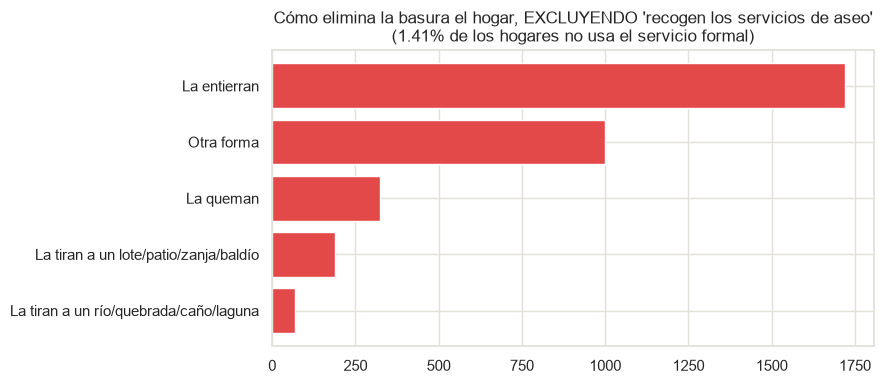

In [29]:
mapa_nhccp37 = {
    1: "La recogen los servicios de aseo", 2: "La tiran a un río/quebrada/caño/laguna",
    3: "La tiran a un lote/patio/zanja/baldío", 4: "La entierran", 5: "La queman", 6: "Otra forma",
}
conteo_nhccp37 = a_numerico(df_em["NHCCP37"]).map(mapa_nhccp37).value_counts()
pct_no_formal = 100 * (1 - conteo_nhccp37.get("La recogen los servicios de aseo", 0) / conteo_nhccp37.sum())

fig, ax = plt.subplots(figsize=(9, 4))
# La categoría dominante ("recogen los servicios de aseo") se omite del gráfico para poder ver
# el detalle de las categorías minoritarias, que de otro modo quedarían invisibles al lado de ~230,000.
conteo_sin_dominante = conteo_nhccp37.drop("La recogen los servicios de aseo")
ax.barh(conteo_sin_dominante.index[::-1], conteo_sin_dominante.values[::-1], color=eda.PALETA_CATEGORICA[5])
ax.set_title(f"Cómo elimina la basura el hogar, EXCLUYENDO 'recogen los servicios de aseo'\n({pct_no_formal:.2f}% de los hogares no usa el servicio formal)")
fig.tight_layout()
plt.show()

### Percepción de cambio 2017→hoy — `NHCLP9C` (basuras), `NHCLP9E` (barrido), `NHCLP9F` (reciclaje)

Estas 3 preguntas piden al hogar comparar cómo ve estos servicios hoy frente a 2017 — es
percepción subjetiva, no un hecho medido, pero es la única variable de todo el proyecto que
pregunta directamente por una tendencia percibida en el tiempo.

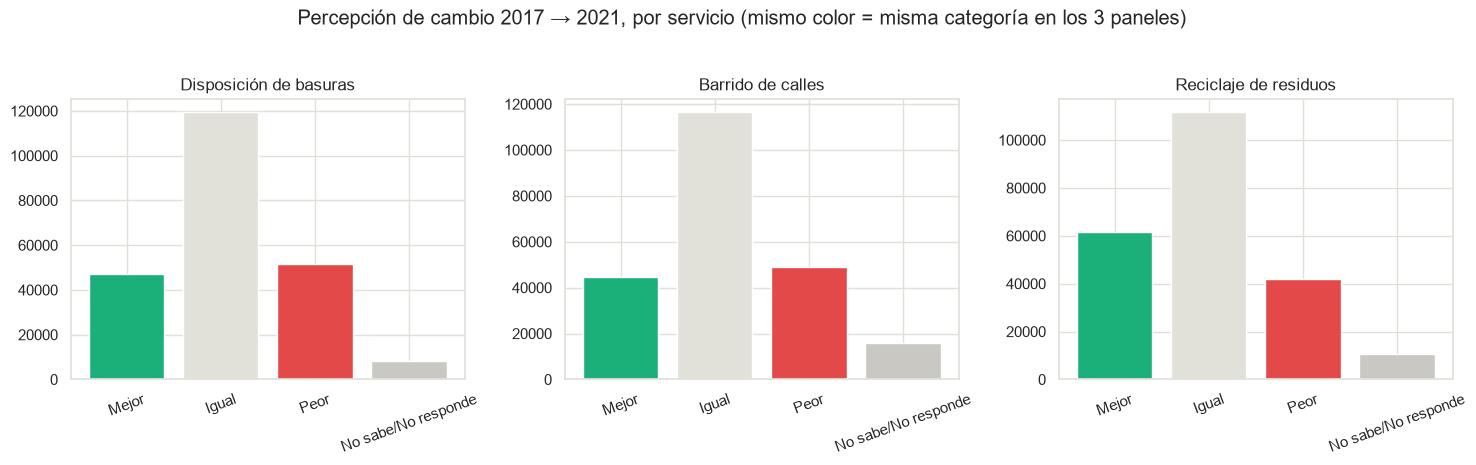

In [30]:
mapa_percepcion = {1: "Mejor", 2: "Igual", 3: "Peor", 9: "No sabe/No responde"}
# Orden FIJO y colores fijos por categoría (no por frecuencia): esta variable es de polaridad
# (mejor/igual/peor), así que el color debe seguir el significado de la categoría, no su
# posición en el ranking de cada panel — si se colorea por posición, el mismo color puede
# representar "Peor" en un panel y "Mejor" en otro (el orden de frecuencia cambia entre los 3
# servicios), lo cual induce a error de lectura.
orden_percepcion = ["Mejor", "Igual", "Peor", "No sabe/No responde"]
colores_percepcion = {"Mejor": eda.PALETA_CATEGORICA[1], "Igual": eda.COLOR_GRID,
                       "Peor": eda.PALETA_CATEGORICA[5], "No sabe/No responde": "#c9c8c2"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, titulo in zip(axes, ["NHCLP9C", "NHCLP9E", "NHCLP9F"], ["Disposición de basuras", "Barrido de calles", "Reciclaje de residuos"]):
    conteo = a_numerico(df_em[col]).map(mapa_percepcion).value_counts().reindex(orden_percepcion)
    ax.bar(conteo.index, conteo.values, color=[colores_percepcion[c] for c in conteo.index])
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Percepción de cambio 2017 → 2021, por servicio (mismo color = misma categoría en los 3 paneles)", y=1.03)
fig.tight_layout()
plt.show()

**Lectura:** si "Igual" domina en las 3 preguntas (lo más común en este tipo de percepción),
sugiere que la mayoría de los hogares no percibe cambios notorios en ninguno de los 3 servicios
en ese período — un dato de contexto útil para no sobre-interpretar mejoras o deterioros que la
gente en general no percibió.

---

## Cierre

Este EDA responde el Objetivo Específico 1 del proyecto de grado con datos reales, cruzando
categorías (no solo describiéndolas por separado), y aprovechando por primera vez el trabajo
geoespacial completo del proyecto. **No decide qué variables entran al ABM** — esa decisión usa
los 3 criterios de la tabla anterior como insumo, en la siguiente fase, cuando el usuario lo
indique.